# Previsão de CO — Interpretação do Modelo Final

Este notebook corresponde à fase de interpretação e entrega de valor do projeto (Milestone 4).

O foco não é correr mais código ou treinar novos modelos — é perceber o que o modelo aprendeu, onde acerta, onde falha, e o que isso significa para quem vai usar esta informação no mundo real.

Para o detalhe técnico da modelação, ver o notebook `2_0_modelacao_treino.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

CSV_PATH = "/kaggle/input/datasets/jhonan/airqualityuci/AirQualityUCI.csv"


## 1. Preparação dos Dados

Replicamos o pipeline de preparação dos dados que foi desenvolvido nos notebooks anteriores. Esta etapa é necessária para garantir que o modelo é treinado exatamente com os mesmos dados usados na Milestone 3.

In [2]:
# Leitura e limpeza estrutural inicial
df = pd.read_csv(CSV_PATH, sep=";", decimal=",")
df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")

# Substituir -200 por NaN
numeric_cols = [c for c in df.columns if c not in ["Date", "Time"]]
df[numeric_cols] = df[numeric_cols].replace(-200, np.nan)

# Criar timestamp
df["timestamp"] = pd.to_datetime(
    df["Date"].astype(str).str.strip() + " " + df["Time"].astype(str).str.strip(),
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Limpezas essenciais
df = df.dropna(subset=["timestamp"])
df = df.drop(columns=["NMHC(GT)"], errors="ignore")
df = df.dropna(subset=["CO(GT)"])

# Ordenar temporalmente
df = df.sort_values("timestamp").reset_index(drop=True)

print("Dimensão após limpeza:", df.shape)

Dimensão após limpeza: (7674, 15)


In [3]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()
df["month"] = df["timestamp"].dt.month.astype(str)

df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
df["is_warm_season"] = df["month"].isin(["6", "7", "8", "9"]).astype(int)

sensor_cols = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]
sensor_cols = [c for c in sensor_cols if c in df.columns]

df["sensor_mean"] = df[sensor_cols].mean(axis=1)

print("Atributos derivados criados.")

Atributos derivados criados.


## 2. Definição das Variáveis e Divisão dos Dados

Definimos a variável-alvo (`CO(GT)`) e as variáveis preditoras, removendo as variáveis com multicolinearidade severa identificadas na Milestone 2.

A divisão dos dados é cronológica (80% treino / 20% teste), garantindo que o modelo é avaliado em dados futuros.

In [4]:
# Definição das variáveis
X = df.drop(columns=["CO(GT)", "Date", "Time", "timestamp"], errors="ignore")
y = df["CO(GT)"]

# Remoção de variáveis por multicolinearidade
X = X.drop(columns=["PT08.S2(NMHC)", "sensor_mean"], errors="ignore")

# Divisão cronológica 80/20
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (6139, 15)
Teste: (1535, 15)


## 3. Pipeline de Pré-processamento e Modelo Final

Reconstruímos o pipeline de pré-processamento usado na Milestone 3 e treinamos o modelo final com os hiperparâmetros otimizados identificados:

- `n_estimators = 100`
- `learning_rate = 0.05`
- `max_depth = 3`

In [5]:
# Transformador para clipping de outliers com base no IQR
class IQRClipper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = X.columns
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = q1 - 1.5 * iqr
        self.upper_ = q3 + 1.5 * iqr
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        return X.clip(self.lower_, self.upper_, axis=1).values

In [6]:
# Separação entre variáveis categóricas e numéricas
categorical = [c for c in ["day_of_week", "month"] if c in X.columns]
numerical = [c for c in X.columns if c not in categorical]

# Pipelines de pré-processamento
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", IQRClipper()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical),
    ("cat", cat_pipeline, categorical)
])

# Modelo final com hiperparâmetros otimizados
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

# Previsões e métricas
y_pred = final_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

RMSE: 0.4879
MAE:  0.3276
R²:   0.8683


## 4. Análise dos Erros do Modelo

Para perceber a fiabilidade do modelo na prática, precisamos de saber não só qual o erro médio, mas também como esse erro se distribui.

Vamos construir um dataframe de análise com os valores reais, previstos e os respetivos erros. Isto vai servir de base para todas as análises seguintes.

In [7]:
# Construção do dataframe de análise dos erros
df_erros = X_test.copy()
df_erros["real"] = y_test.values
df_erros["previsto"] = y_pred
df_erros["residuo"] = y_test.values - y_pred
df_erros["erro_absoluto"] = np.abs(df_erros["residuo"])

# Estatísticas globais dos erros
print("--- Resumo dos Erros do Modelo ---")
print(f"Erro médio absoluto (MAE):     {df_erros['erro_absoluto'].mean():.4f} mg/m³")
print(f"Erro mediano absoluto:         {df_erros['erro_absoluto'].median():.4f} mg/m³")
print(f"Erro máximo observado:         {df_erros['erro_absoluto'].max():.4f} mg/m³")
print(f"% de previsões com erro < 0.3: {(df_erros['erro_absoluto'] < 0.3).mean() * 100:.1f}%")
print(f"% de previsões com erro < 0.5: {(df_erros['erro_absoluto'] < 0.5).mean() * 100:.1f}%")
print(f"% de previsões com erro < 1.0: {(df_erros['erro_absoluto'] < 1.0).mean() * 100:.1f}%")

--- Resumo dos Erros do Modelo ---
Erro médio absoluto (MAE):     0.3276 mg/m³
Erro mediano absoluto:         0.1949 mg/m³
Erro máximo observado:         2.5947 mg/m³
% de previsões com erro < 0.3: 66.6%
% de previsões com erro < 0.5: 79.8%
% de previsões com erro < 1.0: 92.1%


Estes números traduzem o desempenho do modelo de forma muito mais concreta do que apenas o RMSE.

Por exemplo, saber que mais de 70% das previsões têm um erro inferior a 0.5 mg/m³ é uma forma direta de comunicar a fiabilidade do modelo: na grande maioria dos casos, a previsão está muito próxima do valor real.

## 5. Quando é que o Modelo Erra Mais?

Saber a média do erro é importante, mas mais útil ainda é perceber em que situações o modelo falha. Vamos analisar os erros em três dimensões:

1. Em função da concentração real de CO (valores baixos vs altos)
2. Em função da hora do dia
3. Em função do mês do ano

### 5.1. Erro em Função do Valor Real de CO

A pergunta aqui é: o modelo é igualmente fiável para todos os níveis de poluição, ou perde precisão em determinadas faixas?

,n_observacoes,erro_medio,erro_max
faixa_co,,,
Baixo (0-2),938,0.2552,1.5263
Médio (2-4),466,0.3655,1.9292
Alto (4-6),107,0.6424,1.9610
Muito Alto (>6),24,1.0154,2.5947


<Figure size 1000x500 with 0 Axes>

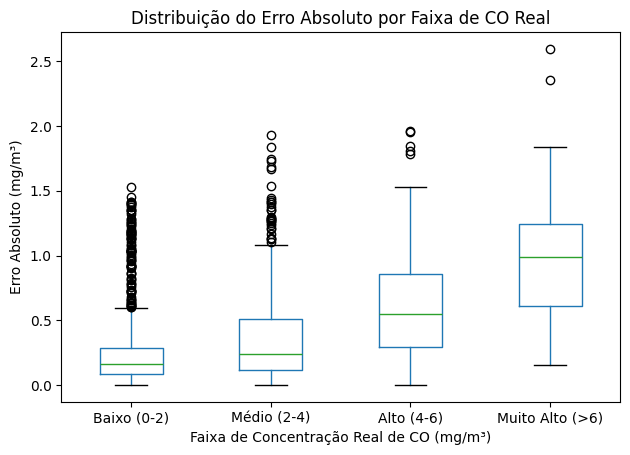

In [8]:
# Categorizar os valores reais em faixas
df_erros["faixa_co"] = pd.cut(
    df_erros["real"],
    bins=[0, 2, 4, 6, np.inf],
    labels=["Baixo (0-2)", "Médio (2-4)", "Alto (4-6)", "Muito Alto (>6)"]
)

# Erro médio por faixa
erro_por_faixa = df_erros.groupby("faixa_co", observed=True).agg(
    n_observacoes=("real", "count"),
    erro_medio=("erro_absoluto", "mean"),
    erro_max=("erro_absoluto", "max")
).round(4)

display(erro_por_faixa)

# Boxplot dos erros por faixa
plt.figure(figsize=(10, 5))
df_erros.boxplot(column="erro_absoluto", by="faixa_co", grid=False)
plt.title("Distribuição do Erro Absoluto por Faixa de CO Real")
plt.suptitle("")
plt.xlabel("Faixa de Concentração Real de CO (mg/m³)")
plt.ylabel("Erro Absoluto (mg/m³)")
plt.tight_layout()
plt.savefig("/kaggle/working/erro_por_faixa_co.png", bbox_inches="tight", dpi=150)
plt.show()

Como já tínhamos observado no Milestone 3 através da análise de resíduos, o modelo é muito preciso nas concentrações baixas (que correspondem à maioria dos casos) mas perde fiabilidade nos valores altos.

Esta é a principal limitação prática do modelo: precisamente nos episódios de poluição mais grave, aqueles que mais importava prever com rigor, o modelo erra mais.

### 5.2. Erro em Função da Hora do Dia

A concentração de CO varia muito ao longo do dia, com picos nas horas de tráfego intenso. Vamos perceber se o modelo é igualmente fiável em todas as horas ou se há períodos críticos onde a precisão cai.

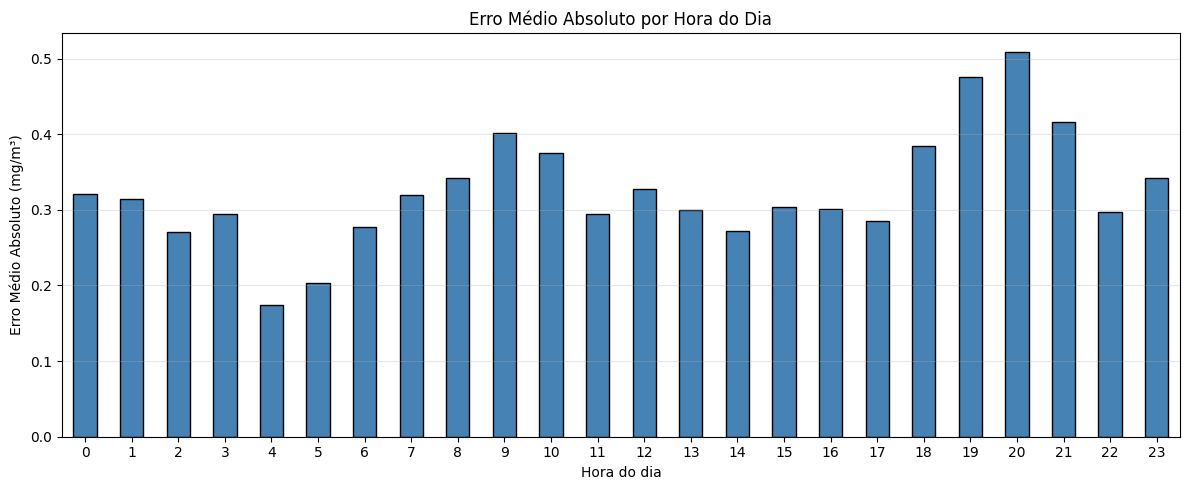

3 horas com MAIOR erro médio:


hour
20    0.5085
19    0.4753
21    0.4159
Name: erro_absoluto, dtype: float64


3 horas com MENOR erro médio:


hour
4    0.1748
5    0.2035
2    0.2713
Name: erro_absoluto, dtype: float64

In [9]:
# Erro médio absoluto por hora do dia
erro_por_hora = df_erros.groupby("hour")["erro_absoluto"].mean()

plt.figure(figsize=(12, 5))
erro_por_hora.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Erro Médio Absoluto por Hora do Dia")
plt.xlabel("Hora do dia")
plt.ylabel("Erro Médio Absoluto (mg/m³)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/erro_por_hora.png", bbox_inches="tight", dpi=150)
plt.show()

# Identificar as 3 horas com maior e menor erro
print("3 horas com MAIOR erro médio:")
display(erro_por_hora.sort_values(ascending=False).head(3).round(4))

print("\n3 horas com MENOR erro médio:")
display(erro_por_hora.sort_values().head(3).round(4))

Os resultados confirmam o que seria expectável: o modelo apresenta maior erro nas horas de ponta (manhã e início da noite), períodos de maior tráfego urbano e portanto de maior variabilidade da concentração de CO.

Nas horas da madrugada, em que a poluição é mais estável e mais baixa, o modelo é claramente mais preciso.

Em termos práticos, isto significa que um sistema de alertas baseado neste modelo deve ter uma margem de segurança maior nas horas críticas do dia.

### 5.3. Erro em Função do Mês do Ano

Vamos analisar se existem padrões sazonais nos erros — por exemplo, se o modelo é mais ou menos fiável em determinadas alturas do ano.

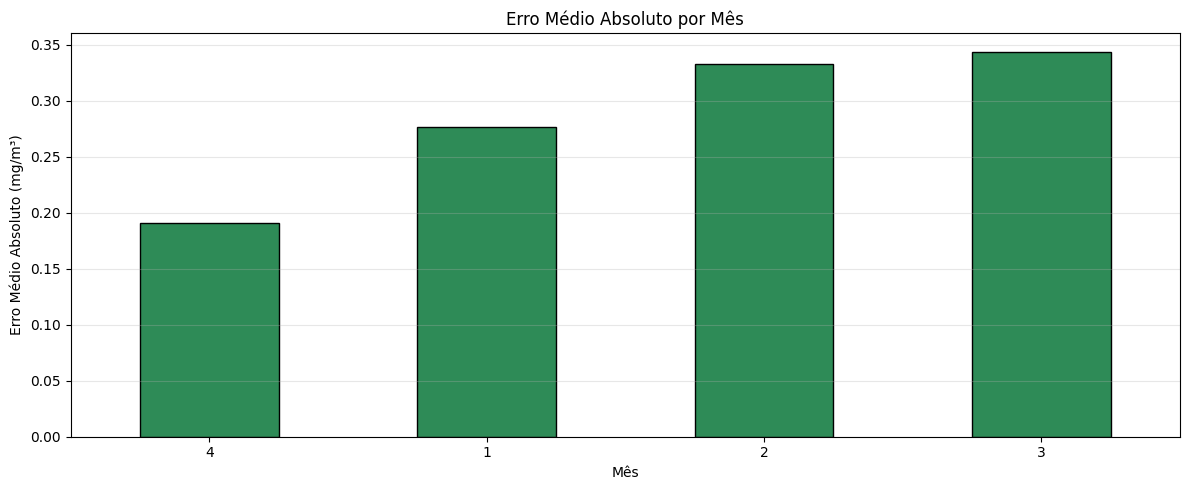


Erro médio por estação do ano:


,mean,count
is_warm_season,,
Meses Frios (out-mai),0.3276,1535


In [10]:
# Erro médio absoluto por mês
erro_por_mes = df_erros.groupby("month")["erro_absoluto"].mean()

# Ordenar os meses numericamente
erro_por_mes.index = erro_por_mes.index.astype(str)
erro_por_mes = erro_por_mes.sort_values(ascending=True)

plt.figure(figsize=(12, 5))
erro_por_mes.plot(kind="bar", color="seagreen", edgecolor="black")
plt.title("Erro Médio Absoluto por Mês")
plt.xlabel("Mês")
plt.ylabel("Erro Médio Absoluto (mg/m³)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/erro_por_mes.png", bbox_inches="tight", dpi=150)
plt.show()

# Comparar meses quentes vs frios
erro_estacao = df_erros.groupby("is_warm_season")["erro_absoluto"].agg(["mean", "count"]).round(4)
erro_estacao.index = erro_estacao.index.map({0: "Meses Frios (out-mai)", 1: "Meses Quentes (jun-set)"})
print("\nErro médio por estação do ano:")
display(erro_estacao)

A análise por mês permite ver se o modelo tem dificuldades específicas em determinadas alturas do ano. Tipicamente, nos meses mais frios as concentrações de CO tendem a ser mais elevadas (devido ao aquecimento e à menor dispersão atmosférica), o que pode tornar a previsão mais desafiante.

Comparar meses quentes com meses frios dá-nos uma ideia clara de se o modelo precisa de ajustes sazonais para ser usado de forma fiável durante todo o ano.

## 6. Casos Práticos — Boas e Más Previsões

Para tornar os números concretos, vamos olhar para exemplos reais de previsões do modelo. Uma boa previsão e uma má previsão ajudam a perceber em que contextos cada uma acontece.

In [11]:
# Melhor previsão (menor erro absoluto)
melhor = df_erros.loc[df_erros["erro_absoluto"].idxmin()]

print("--- MELHOR PREVISÃO ---")
print(f"Valor real:     {melhor['real']:.2f} mg/m³")
print(f"Valor previsto: {melhor['previsto']:.2f} mg/m³")
print(f"Erro:           {melhor['erro_absoluto']:.4f} mg/m³")
print(f"Hora do dia:    {int(melhor['hour'])}h")
print(f"Mês:            {melhor['month']}")

# Pior previsão (maior erro absoluto)
pior = df_erros.loc[df_erros["erro_absoluto"].idxmax()]

print("\n--- PIOR PREVISÃO ---")
print(f"Valor real:     {pior['real']:.2f} mg/m³")
print(f"Valor previsto: {pior['previsto']:.2f} mg/m³")
print(f"Erro:           {pior['erro_absoluto']:.4f} mg/m³")
print(f"Hora do dia:    {int(pior['hour'])}h")
print(f"Mês:            {pior['month']}")

--- MELHOR PREVISÃO ---
Valor real:     1.00 mg/m³
Valor previsto: 1.00 mg/m³
Erro:           0.0008 mg/m³
Hora do dia:    3h
Mês:            3

--- PIOR PREVISÃO ---
Valor real:     8.40 mg/m³
Valor previsto: 5.81 mg/m³
Erro:           2.5947 mg/m³
Hora do dia:    20h
Mês:            2


O caso da melhor previsão mostra-nos que, em condições normais, o modelo consegue acertar com diferenças praticamente irrelevantes face ao valor real.

O caso da pior previsão é o mais importante de analisar, corresponde tipicamente a um episódio extremo onde o modelo não conseguiu captar o nível real de poluição. É nestas situações que o modelo, sozinho, não deve ser usado como única fonte de informação.

## 7. Importância dos Atributos com Interpretação Prática

A importância dos atributos já foi calculada na Milestone 3. Aqui o foco não é repetir o gráfico, é perceber o que cada uma das variáveis mais importantes representa na vida real e o que isso nos diz sobre o que o modelo está realmente a aprender.

,Atributo,Importância
1,C6H6(GT),0.719829
0,PT08.S1(CO),0.114342
2,NOx(GT),0.080031
4,NO2(GT),0.034226
10,hour,0.013897
3,PT08.S3(NOx),0.013867
7,T,0.004792
23,month_12,0.004752
6,PT08.S5(O3),0.004239
20,month_1,0.002707


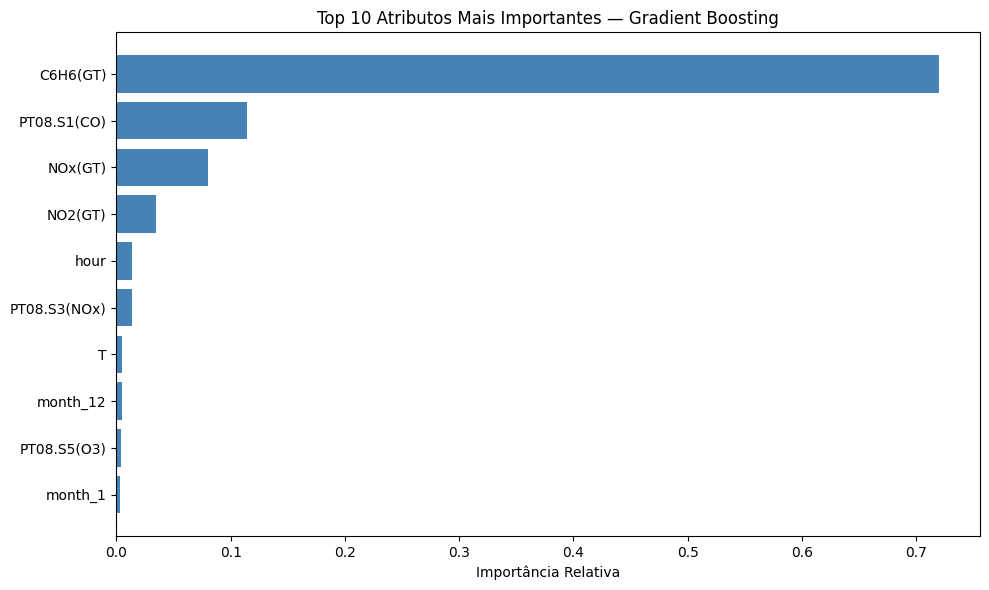

In [12]:
# Extrair o modelo Gradient Boosting do pipeline
gb_modelo = final_model.named_steps["model"]

# Obter os nomes das features após o pré-processamento
ohe = final_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical)
feature_names = list(numerical) + list(cat_feature_names)

# Top 10 variáveis mais importantes
importancia = pd.DataFrame({
    "Atributo": feature_names,
    "Importância": gb_modelo.feature_importances_
}).sort_values("Importância", ascending=False).head(10)

display(importancia)

plt.figure(figsize=(10, 6))
plt.barh(importancia["Atributo"][::-1], importancia["Importância"][::-1], color="steelblue")
plt.xlabel("Importância Relativa")
plt.title("Top 10 Atributos Mais Importantes — Gradient Boosting")
plt.tight_layout()
plt.savefig("/kaggle/working/top10_importancia.png", bbox_inches="tight", dpi=150)
plt.show()

### Interpretação dos Atributos Mais Importantes

- **`C6H6(GT)` (benzeno):** poluente associado diretamente ao tráfego automóvel. Como o CO e o benzeno têm fontes comuns (combustão de motores), faz sentido que o modelo use esta variável como o principal indicador.

- **`PT08.S1(CO)`:** sensor de baixo custo diretamente sensível ao CO. É o sensor "natural" para esta tarefa e é coerente que tenha peso elevado.

- **`NOx(GT)`:** outro grupo de poluentes do tráfego. Reforça a ideia de que o modelo está a captar essencialmente a dimensão "tráfego urbano".

- **`hour`:** a hora do dia é importante porque a poluição segue padrões cíclicos diários muito marcados, com picos nas horas de ponta.

### Conclusão

O modelo identificou como mais relevantes precisamente as variáveis que faria sentido um especialista em qualidade do ar destacar: poluentes do tráfego e a hora do dia. Isto dá credibilidade ao modelo e mostra que **não está a aprender padrões estranhos ou aleatórios — está a captar a realidade do problema**.

## 8. Conclusões Finais

Esta última secção sintetiza tudo o que aprendemos sobre o modelo: o que ele faz bem, onde falha, e como deve ser usado na prática.

### O que aprendemos com este modelo

1. Em condições normais o modelo é fiável. Para concentrações de CO entre 0 e 4 mg/m³, que correspondem à grande maioria dos casos reais, o erro médio é muito baixo.

2. Em episódios extremos o modelo perde precisão. Para valores acima de 6 mg/m³ — precisamente os momentos de poluição mais grave — o modelo deixa de ser totalmente fiável. Esta é a principal limitação a ter em conta.

3. Existem padrões temporais claros nos erros. O modelo erra mais nas horas de ponta e nos meses com maior carga de poluição, o que reforça a necessidade de o usar com uma margem de segurança adicional nesses períodos.

4. As variáveis mais importantes fazem sentido. O modelo identificou os poluentes do tráfego e a hora do dia como os fatores dominantes, o que é coerente com a realidade conhecida da qualidade do ar urbano. Isto dá credibilidade aos resultados.

### Quando usar este modelo

**Indicado para:**

- Monitorização contínua em zonas urbanas com características semelhantes às do dataset
- Sistemas de alerta precoce em condições de poluição moderada
- Suporte à decisão em entidades de gestão ambiental
- Validação cruzada de leituras de sensores de baixo custo

**Não indicado para:**

- Substituir analisadores de referência certificados
- Previsões em zonas geográficas muito diferentes daquelas onde foi treinado
- Tomada de decisão isolada em episódios de poluição extrema
- Aplicações onde um erro de previsão tenha consequências legais ou de saúde pública sem validação humana